# Marvel Comics — Deep Regex Analysis

**Dataset:** `Marvel_Comics.csv` — 34,992 issues (de-duplicated)
**Author:** Waheed

A second, deeper pass over the Marvel catalogue using regular expressions to go *beyond*
surface counts:

1. **Enhanced hero ranking** — full character/team names, including groups (the X-Men),
   plus a specialised breakdown of individual X-Men members
2. **Theme analysis** — regex mining of the issue descriptions to profile recurring themes
3. **Strategic extraction** — using regex to surface publishing patterns (serialisation,
   crossovers, key issues, events) that raw columns don't expose

In [1]:
import sys, re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# UTF-8 avoids the mojibake seen with latin-1 in the descriptions
df = pd.read_csv("Marvel_Comics.csv", encoding="utf-8").drop_duplicates()

names = df["comic_name"].dropna().astype(str)
desc  = df["issue_description"].dropna().astype(str)
N_DESC = len(desc)
print(f"{len(df):,} unique issues | {N_DESC:,} with a description")

34,853 unique issues | 30,301 with a description


## Task 1 — Enhanced hero ranking (full names + groups)

Instead of loose keywords, each entry uses a regex that captures a character or team by
its **full identity**, grouping alternate titles together (e.g. *Uncanny X-Men*, *X-Force*
and *X-Factor* all count toward **the X-Men**).

In [2]:
roster = {
    "The X-Men (group)":              r"X-Men|Uncanny X-Men|X-Force|X-Factor|New Mutants",
    "Spider-Man":                     r"Spider-Man|Spider-Woman|Spider-Gwen|Spectacular Spider",
    "The Avengers (group)":           r"Avengers",
    "The Fantastic Four (group)":     r"Fantastic Four",
    "The Incredible Hulk":            r"Hulk",
    "Captain America":                r"Captain America",
    "Wolverine":                      r"Wolverine",
    "Iron Man":                       r"Iron Man|Invincible Iron",
    "Thor":                           r"\bThor\b|Mighty Thor",
    "Daredevil":                      r"Daredevil",
    "The Punisher":                   r"Punisher",
    "Deadpool":                       r"Deadpool",
    "Doctor Strange":                 r"Doctor Strange|Dr\. Strange",
    "Guardians of the Galaxy (group)":r"Guardians of the Galaxy",
    "Ghost Rider":                    r"Ghost Rider",
}
roster_pat = {k: re.compile(v, re.IGNORECASE) for k, v in roster.items()}
top_roster = (pd.Series({k: names.apply(lambda t: bool(p.search(t))).sum()
                         for k, p in roster_pat.items()})
              .sort_values(ascending=False).head(10))
top_roster

The X-Men (group)             3386
Spider-Man                    3235
The Avengers (group)          2147
The Fantastic Four (group)    1070
The Incredible Hulk           1032
Captain America               1000
Wolverine                      951
Iron Man                       879
Thor                           861
Daredevil                      761
dtype: int64

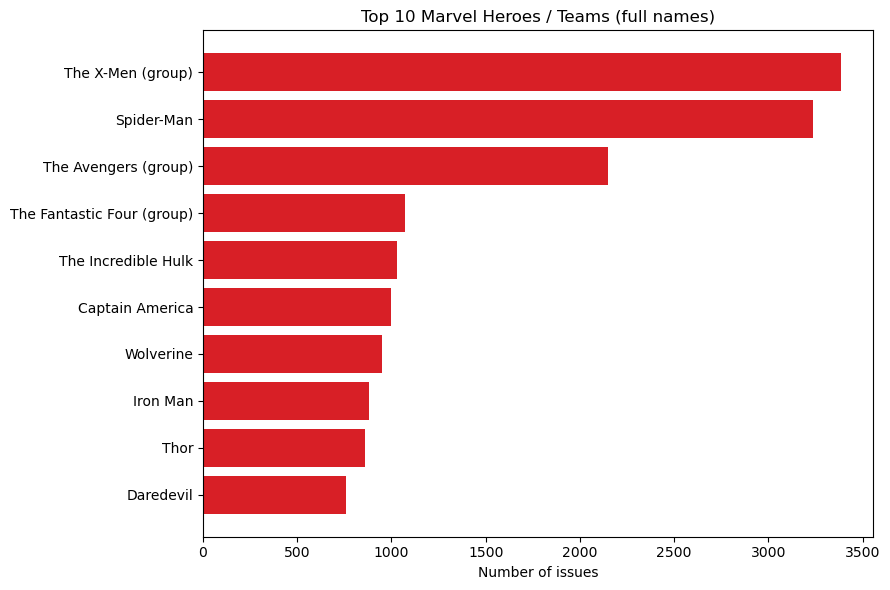

In [3]:
top10 = top_roster.iloc[::-1]
plt.figure(figsize=(9, 6))
plt.barh(top10.index, top10.values, color="#d81f26")
plt.xlabel("Number of issues"); plt.title("Top 10 Marvel Heroes / Teams (full names)")
plt.tight_layout(); plt.show()

### Specialised: individual X-Men members

The group ranking hides *who inside the team* carries the most issues. Here we regex each
member against the series titles.

In [4]:
xmen = {
    "Wolverine": r"Wolverine", "Cable": r"\bCable\b", "Gambit": r"Gambit",
    "Rogue": r"\bRogue\b", "Jean Grey / Phoenix": r"Jean Grey|Phoenix|Marvel Girl",
    "Magneto": r"Magneto", "Storm": r"\bStorm\b", "Nightcrawler": r"Nightcrawler",
    "Mystique": r"Mystique", "Cyclops": r"Cyclops", "Colossus": r"Colossus",
    "Iceman": r"Iceman", "Psylocke": r"Psylocke", "Emma Frost": r"Emma Frost",
    "Kitty Pryde / Shadowcat": r"Kitty Pryde|Shadowcat", "Professor X": r"Professor X",
}
xmen_pat = {k: re.compile(v, re.IGNORECASE) for k, v in xmen.items()}
top_xmen = (pd.Series({k: names.apply(lambda t: bool(p.search(t))).sum()
                       for k, p in xmen_pat.items()})
            .sort_values(ascending=False).head(10))
top_xmen

Wolverine              951
Cable                  261
Gambit                  93
Rogue                   67
Jean Grey / Phoenix     65
Magneto                 45
Storm                   35
Nightcrawler            34
Mystique                29
Cyclops                 28
dtype: int64

**Interpretation — Task 1.**
Grouping alternate titles flips the #1 slot: **the X-Men franchise (~3,386 issues)** narrowly
overtakes **Spider-Man (~3,235)** once *Uncanny X-Men*, *X-Force* and *X-Factor* are counted
together — a reframing the surface-level per-title count missed. Within the X-Men,
**Wolverine dominates by a wide margin (~951 issues)**, followed by **Cable (~261)** — the
two members with long-running solo titles. Members like Storm or Cyclops appear far less as
*title* characters because they mostly feature inside team books rather than headlining
their own.

## Task 2 — Theme analysis of issue descriptions

Each theme is a regex covering its vocabulary (with `\w*` to catch word variants such as
*kill / killed / killing*). We measure the share of the 30,301 described issues that touch
each theme.

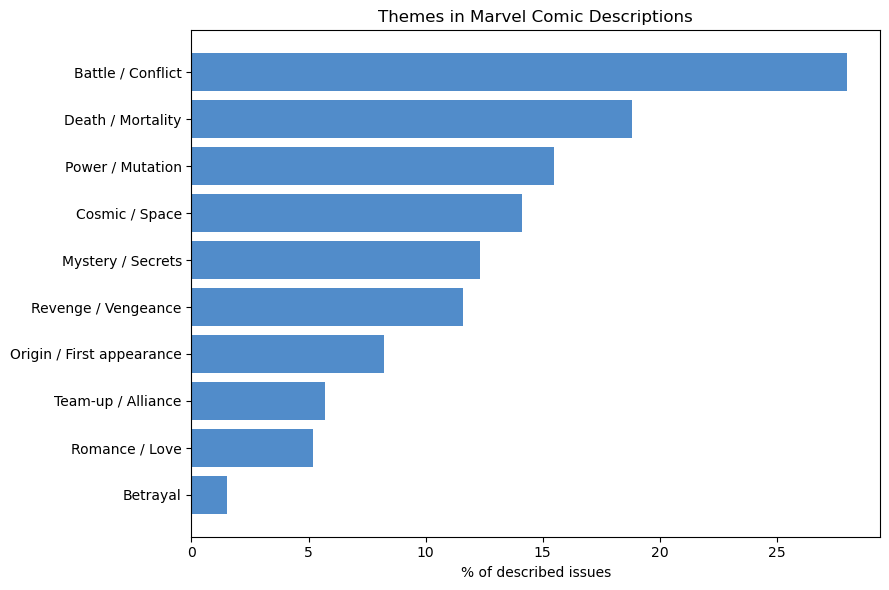

,issues,pct_of_described
Battle / Conflict,8488,28.0
Death / Mortality,5694,18.8
Power / Mutation,4695,15.5
Cosmic / Space,4273,14.1
Mystery / Secrets,3717,12.3
Revenge / Vengeance,3512,11.6
Origin / First appearance,2471,8.2
Team-up / Alliance,1729,5.7
Romance / Love,1589,5.2
Betrayal,440,1.5


In [5]:
themes = {
    "Battle / Conflict":         r"(?i)\b(?:battle|fight|war|clash|showdown|confront|attack)\w*",
    "Death / Mortality":         r"(?i)\b(?:death|dies|died|dead|kill|murder|grave|funeral)\w*",
    "Power / Mutation":          r"(?i)\b(?:power|transform|mutation|mutant|evolve)\w*",
    "Cosmic / Space":            r"(?i)\b(?:cosmic|galaxy|universe|alien|planet|space)\w*",
    "Mystery / Secrets":         r"(?i)\b(?:mystery|secret|hidden|reveal|conspiracy)\w*",
    "Revenge / Vengeance":       r"(?i)\b(?:revenge|vengeance|avenge)\w*",
    "Origin / First appearance": r"(?i)\b(?:origin|debut|begins|born)\w*|(?:1st|first) appearance",
    "Team-up / Alliance":        r"(?i)(?:team[- ]up|join forces|guest[- ]star|alliance)",
    "Romance / Love":            r"(?i)\b(?:love|romance|kiss|wedding|marriage|heart)\w*",
    "Betrayal":                  r"(?i)\b(?:betray|traitor|deceit|treachery)\w*",
}
theme_tbl = pd.Series({k: desc.str.contains(v, regex=True).sum()
                       for k, v in themes.items()}).sort_values(ascending=False).to_frame("issues")
theme_tbl["pct_of_described"] = (theme_tbl["issues"] / N_DESC * 100).round(1)

t = theme_tbl["pct_of_described"].iloc[::-1]
plt.figure(figsize=(9, 6))
plt.barh(t.index, t.values, color="#518cca")
plt.xlabel("% of described issues"); plt.title("Themes in Marvel Comic Descriptions")
plt.tight_layout(); plt.show()
theme_tbl

**Interpretation — Task 2.**
Marvel's storytelling is overwhelmingly **conflict-driven**: ~28% of descriptions invoke
battle/fighting and ~19% touch death or mortality. **Power/mutation (~15.5%)** and
**cosmic/space (~14%)** themes reflect the franchise's superpowered and galactic scope,
while **romance (~5%)** and **betrayal (~1.5%)** are comparatively rare — Marvel sells
action far more than it sells drama.

## Task 3 — Strategic extraction: publishing patterns

Regex can surface *structural* facts the columns never store — how stories are serialised,
which issues are marketed as key/collectible, and which crossover events dominate.

In [6]:
insights = {
    "Serialized ('Part N')":          r"(?i)\bpart\s+\d+\b",
    "Conflict ('vs' / 'versus')":     r"(?i)\b(?:vs\.?|versus)\b",
    "Crossover ('guest-star')":       r"(?i)guest[- ]star",
    "Character death":                r"(?i)\b(?:death of|dies|is killed|killed by)",
    "Key issue ('first appearance')": r"(?i)\b(?:1st|first)\s+appearance",
}
insight_tbl = pd.Series({k: desc.str.contains(v, regex=True).sum()
                         for k, v in insights.items()}).sort_values(ascending=False).to_frame("issues")
insight_tbl["pct"] = (insight_tbl["issues"] / N_DESC * 100).round(1)
print(insight_tbl.to_string())

# Which crossover EVENTS get name-dropped? (emphasised ALLCAPS entities in the copy)
caps_re = re.compile(r"\b[A-Z][A-Z0-9'\-]{2,}\b")
skip = {"THE","AND","BUT","FOR","NOT","YOU","ALL","NEW","NOW","ONE","OUT","WHO","WHAT","WHEN",
        "THIS","THAT","PLUS","FREE","PART","WILL","MARVEL","COMIC","ISSUE","SERIES","MORE","FROM",
        "PGS","TIE-IN","SUGGESTED","TEENS","PARENTAL","ADVISORY","RATED","PSR","ISBN","MAN","AMAZING",
        "ONGOING","VARIANT","MATURE","READERS","COVER","GUEST","STARRING","COLLECTS","REPRINTS","FCBD","FOUR"}
caps = Counter()
for s in desc:
    for w in caps_re.findall(s):
        if w not in skip and len(w) > 2:
            caps[w] += 1
print("\nMost-emphasised entities/events in marketing copy:")
for name, c in caps.most_common(15):
    print(f"  {c:4d}  {name}")

                                issues  pct
Serialized ('Part N')             2363  7.8
Conflict ('vs' / 'versus')        1244  4.1
Crossover ('guest-star')           947  3.1
Character death                    404  1.3
Key issue ('first appearance')     229  0.8



Most-emphasised entities/events in marketing copy:
   876  X-MEN
   810  SPIDER-MAN
   771  AVENGERS
   704  WAR
   410  HULK
   353  CIVIL
   341  IRON
   328  CAPTAIN
   317  FANTASTIC
   312  SECRET
   307  WOLVERINE
   292  ULTIMATE
   261  AMERICA
   243  THOR
   243  BLACK


**Interpretation — Task 3.**
The descriptions reveal *how Marvel publishes*, not just what: nearly **8% of issues are
explicitly serialised** ("Part 3"), confirming that multi-issue arcs are the backbone of the
line. About **4% pit heroes against a named foe** ("vs"), and **3% advertise a guest-star** —
crossovers are a core sales lever. Only **~0.8% tout a "first appearance,"** which makes those
few genuinely rare (and collectible) key issues.

Mining the ALLCAPS emphasis surfaces the big **crossover events** as recurring keywords —
`CIVIL` + `WAR` (Civil War), `SECRET` (Secret Wars / Secret Invasion) — showing how
line-wide events, not just characters, drive the catalogue.

## Summary

- **Grouping matters:** counting the X-Men's alternate titles together makes the franchise
  Marvel's #1 by issue count, edging out Spider-Man — a conclusion the per-title view hid.
- **Wolverine is the X-Men's workhorse**, carrying more solo issues than the rest of the roster combined.
- **Marvel is a conflict-first publisher:** battle and death dominate the themes; romance and betrayal are rare.
- **Regex exposes structure the columns don't store:** serialisation, crossovers, key issues,
  and named crossover *events* (Civil War, Secret Wars) — genuinely new perspective on the data.